In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("antobenedetti/animals")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 882M/882M [00:07<00:00, 119MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/antobenedetti/animals/versions/5
Contents of base_path (/root/.cache/kagglehub/datasets/antobenedetti/animals/versions):
['5']
Contents of path (/root/.cache/kagglehub/datasets/antobenedetti/animals/versions/5):
['animals']


In [ ]:
import os

dataset_dir = os.path.join(path, 'animals')
sub_folders = ['train', 'val', 'inf']

for folder in sub_folders:
    folder_path = os.path.join(dataset_dir, folder)
    if os.path.exists(folder_path):
        animal_classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        print(f"Folder '{folder}' contains {len(animal_classes)} animal classes.")
        print(f"Example classes: {animal_classes[:5]}\n")

Folder 'train' contains 5 animal classes.
Example classes: ['cat', 'lion', 'horse', 'elephant', 'dog']

Folder 'val' contains 5 animal classes.
Example classes: ['cat', 'lion', 'horse', 'elephant', 'dog']

Folder 'inf' contains 0 animal classes.
Example classes: []



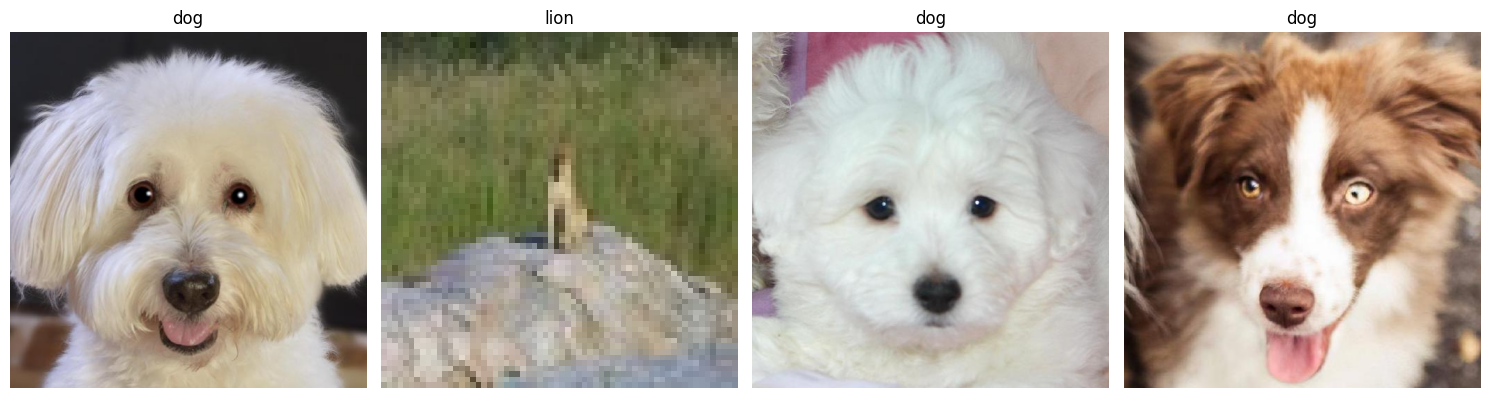

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

plt.figure(figsize=(15, 10))

train_dir = os.path.join(dataset_dir, 'train')
animal_types = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for i in range(4):
    selected_animal = random.choice(animal_types)
    animal_folder = os.path.join(train_dir, selected_animal)
    images = [f for f in os.listdir(animal_folder) if os.path.isfile(os.path.join(animal_folder, f))]

    if images:
        random_img = random.choice(images)
        img_path = os.path.join(animal_folder, random_img)
        img = mpimg.imread(img_path)
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(selected_animal)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Define transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(dataset_dir, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(dataset_dir, 'val'), data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
}

# Load pre-trained VGG16 and modify for our classes
model = models.vgg16(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, len(image_datasets['train'].classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Training Loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
num_epochs = 10

for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'Epoch {epoch}/{num_epochs - 1} {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0/9 train Loss: 0.6548 Acc: 0.9225
Epoch 0/9 val Loss: 0.4287 Acc: 0.9405
Epoch 1/9 train Loss: 0.7392 Acc: 0.9485
Epoch 1/9 val Loss: 0.8055 Acc: 0.9626
Epoch 2/9 train Loss: 0.7090 Acc: 0.9555
Epoch 2/9 val Loss: 0.8940 Acc: 0.9606
Epoch 3/9 train Loss: 0.2817 Acc: 0.9711
Epoch 3/9 val Loss: 0.9986 Acc: 0.9679
Epoch 4/9 train Loss: 1.2879 Acc: 0.9678
Epoch 4/9 val Loss: 1.4762 Acc: 0.9392
Epoch 5/9 train Loss: 0.5241 Acc: 0.9755
Epoch 5/9 val Loss: 0.2776 Acc: 0.9746
Epoch 6/9 train Loss: 0.5068 Acc: 0.9815
Epoch 6/9 val Loss: 0.3318 Acc: 0.9719
Epoch 7/9 train Loss: 0.5623 Acc: 0.9797
Epoch 7/9 val Loss: 0.6758 Acc: 0.9613
Epoch 8/9 train Loss: 1.5915 Acc: 0.9734
Epoch 8/9 val Loss: 1.4674 Acc: 0.9733
Epoch 9/9 train Loss: 0.3759 Acc: 0.9824
Epoch 9/9 val Loss: 0.7021 Acc: 0.9780


In [ ]:
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Classes: {image_datasets['train'].classes}")

--- Training Summary ---
Final Training Accuracy: 0.9824
Final Validation Accuracy: 0.9780
Classes: ['cat', 'dog', 'elephant', 'horse', 'lion']


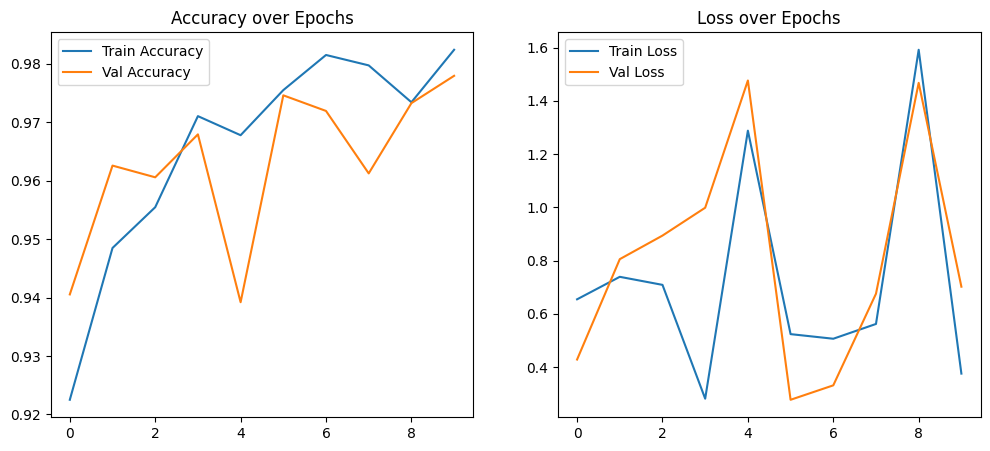

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()